In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv(r"ecommerce_dataset.csv")
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       200 non-null    int64  
 1   Order_Date     200 non-null    object 
 2   City           200 non-null    object 
 3   Category       200 non-null    object 
 4   Product        200 non-null    object 
 5   Quantity       200 non-null    int64  
 6   Unit_Price     200 non-null    int64  
 7   Discount       200 non-null    int64  
 8   Sales          200 non-null    float64
 9   Cost           200 non-null    float64
 10  Profit         200 non-null    float64
 11  Payment_Mode   200 non-null    object 
 12  Rating         200 non-null    int64  
 13  Delivery_Days  200 non-null    int64  
dtypes: float64(3), int64(6), object(5)
memory usage: 22.0+ KB


(200, 14)

In [2]:
df.isnull().sum()

Order_ID         0
Order_Date       0
City             0
Category         0
Product          0
Quantity         0
Unit_Price       0
Discount         0
Sales            0
Cost             0
Profit           0
Payment_Mode     0
Rating           0
Delivery_Days    0
dtype: int64

In [3]:
df.duplicated().sum()

0

In [6]:
sns.set_theme(style="whitegrid")

# 1. Line Plot

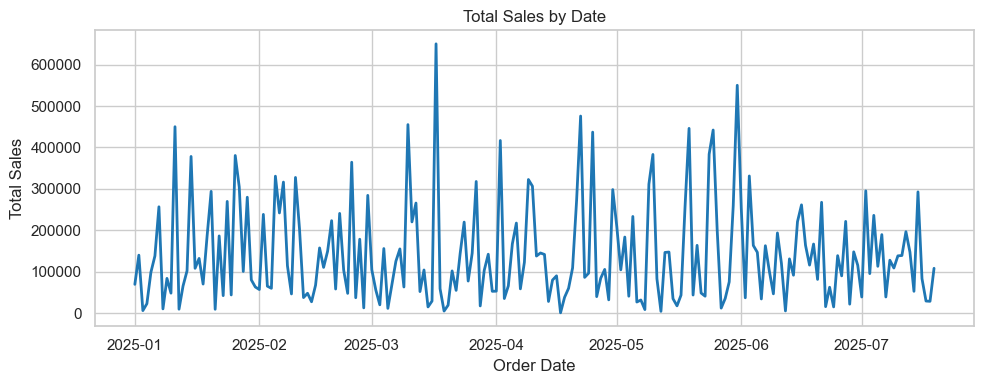

In [7]:
# 1. Plot total sales by date
sales_by_date = df.groupby("Order_Date")["Sales"].sum().reset_index()
plt.figure(figsize=(10, 4))
plt.plot(
    sales_by_date["Order_Date"],
    sales_by_date["Sales"],
    color="tab:blue",
    linewidth=2,
)
plt.title("Total Sales by Date")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

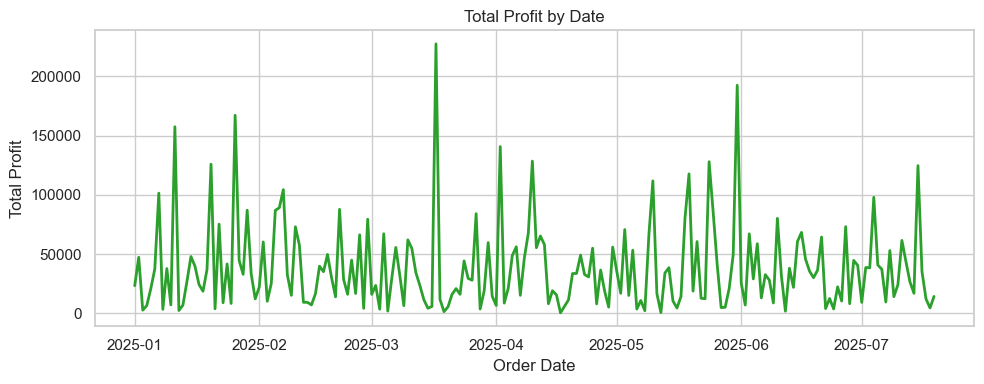

In [8]:
# 2. Plot total profit by date
profit_by_date = df.groupby("Order_Date")["Profit"].sum().reset_index()
plt.figure(figsize=(10, 4))
plt.plot(
    profit_by_date["Order_Date"],
    profit_by_date["Profit"],
    color="tab:green",
    linewidth=2,
)
plt.title("Total Profit by Date")
plt.xlabel("Order Date")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

Highest Sales Month: 2025-05 with Sales: 4972117.25


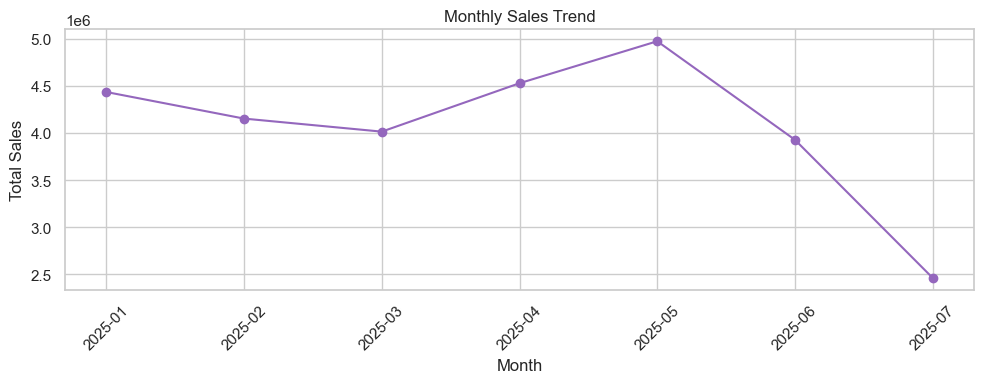

In [9]:
# 3. Plot monthly sales and identify the highest-sales month
df["Year_Month"] = df["Order_Date"].dt.to_period("M")
monthly_sales = (
    df.groupby("Year_Month")["Sales"].sum().reset_index().astype({"Year_Month": str})
)

highest_sales_month = monthly_sales.loc[monthly_sales["Sales"].idxmax()]
print(
    f"Highest Sales Month: {highest_sales_month['Year_Month']} with Sales: {highest_sales_month['Sales']}"
)

plt.figure(figsize=(10, 4))
plt.plot(
    monthly_sales["Year_Month"],
    monthly_sales["Sales"],
    marker="o",
    color="tab:purple",
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Bar Plot

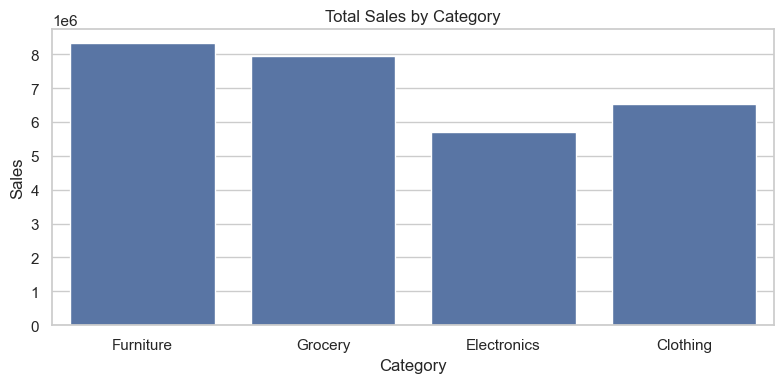

In [10]:
# 4. Compare sales across different product categories
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="Category", y="Sales", estimator=sum, errorbar=None)
plt.title("Total Sales by Category")
plt.tight_layout()
plt.show()

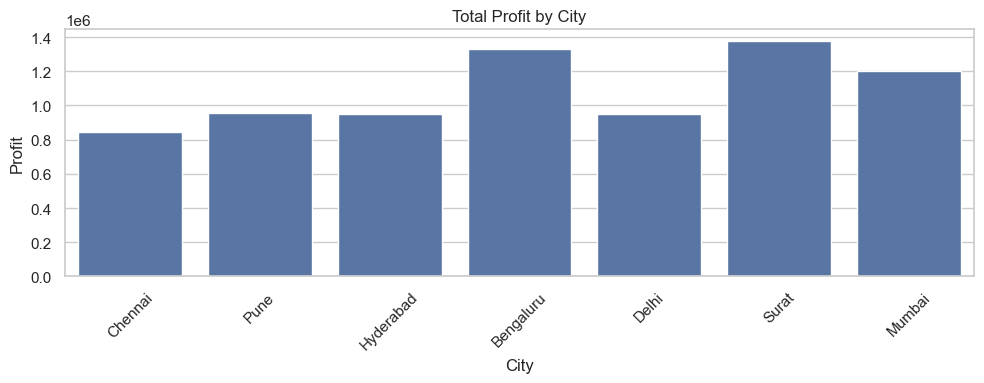

In [11]:
# 5. Compare profit across cities
plt.figure(figsize=(10, 4))
sns.barplot(data=df, x="City", y="Profit", estimator=sum, errorbar=None)
plt.title("Total Profit by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_6344\399031863.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_products, x="Sales", y="Product", palette="Blues_r")


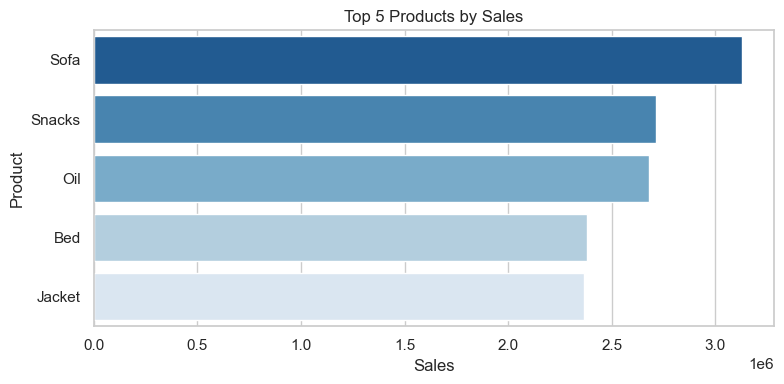

In [12]:
# 6. Find the top 5 products by sales
top5_products = (
    df.groupby("Product")["Sales"].sum().nlargest(5).reset_index()
)
plt.figure(figsize=(8, 4))
sns.barplot(data=top5_products, x="Sales", y="Product", palette="Blues_r")
plt.title("Top 5 Products by Sales")
plt.tight_layout()
plt.show()

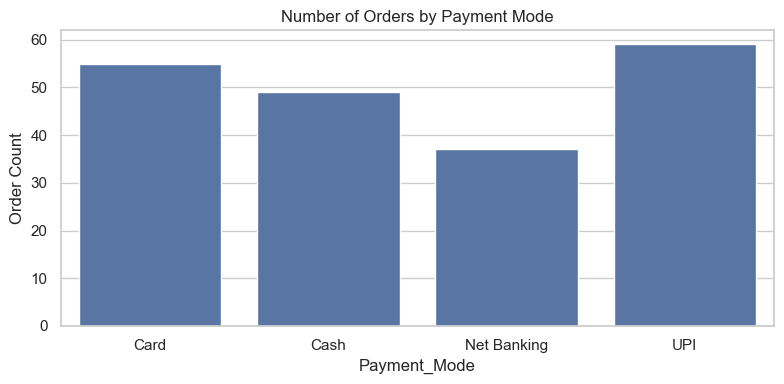

In [13]:
# 7. Compare the number of orders for each payment mode
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Payment_Mode")
plt.title("Number of Orders by Payment Mode")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

# 3. Histogram

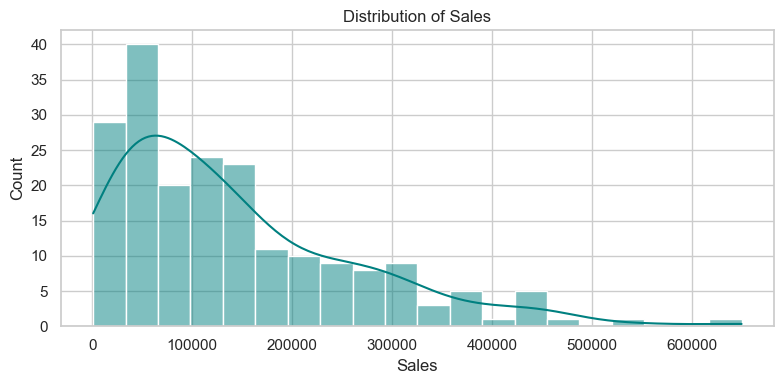

In [14]:
# 8. Plot the distribution of Sales
plt.figure(figsize=(8, 4))
sns.histplot(df["Sales"], kde=True, bins=20, color="teal")
plt.title("Distribution of Sales")
plt.tight_layout()
plt.show()

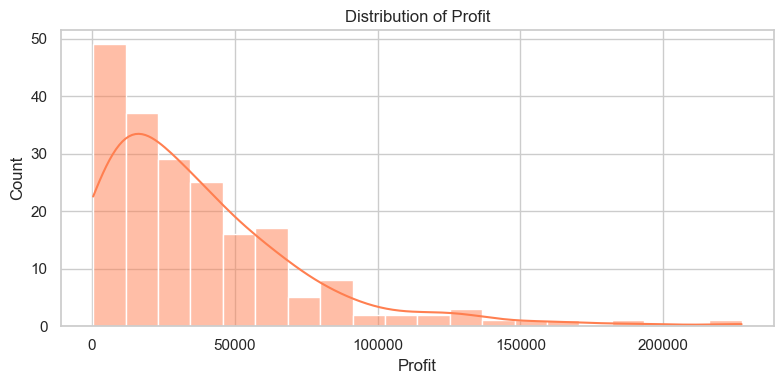

In [15]:
# 9. Plot the distribution of Profit
plt.figure(figsize=(8, 4))
sns.histplot(df["Profit"], kde=True, bins=20, color="coral")
plt.title("Distribution of Profit")
plt.tight_layout()
plt.show()

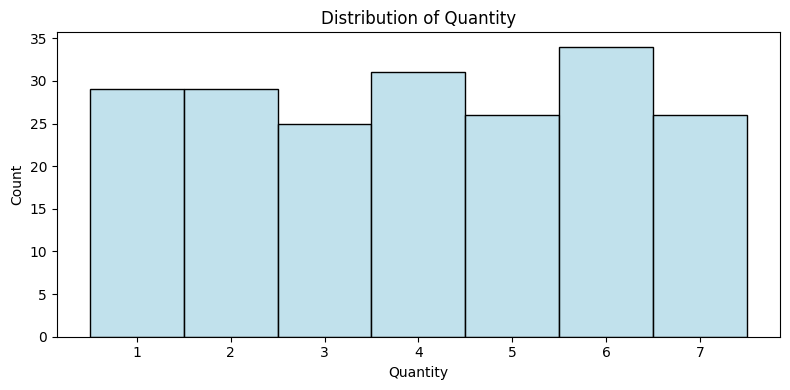

In [6]:
# 10. Plot the distribution of Quantity
plt.figure(figsize=(8, 4))
sns.histplot(df["Quantity"], discrete=True, color="lightblue")
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

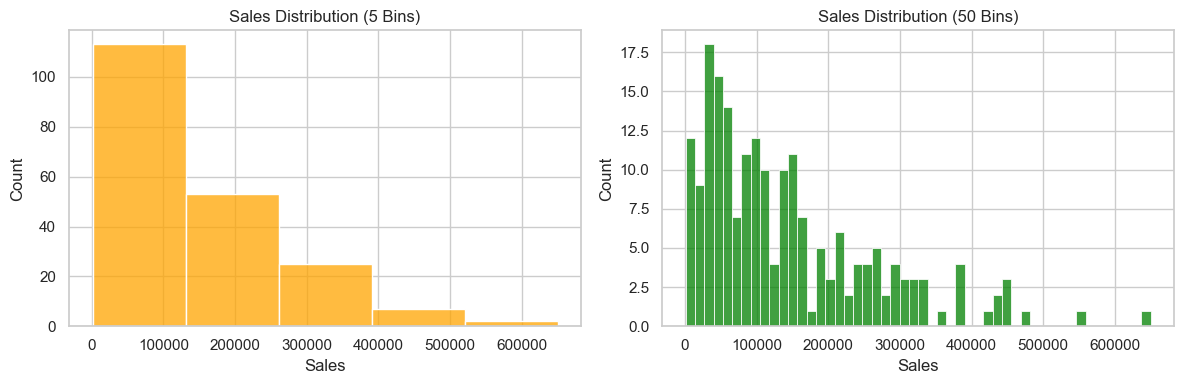

In [17]:
# 11. Change the number of bins and observe the difference
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Sales"], bins=5, ax=axes[0], color="orange")
axes[0].set_title("Sales Distribution (5 Bins)")

sns.histplot(df["Sales"], bins=50, ax=axes[1], color="green")
axes[1].set_title("Sales Distribution (50 Bins)")
plt.tight_layout()
plt.show()

# 4. Box Plot

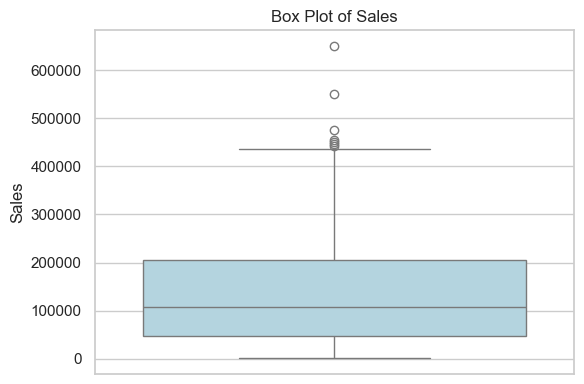

In [18]:
# 12. Create a box plot for Sales
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Sales"], color="lightblue")
plt.title("Box Plot of Sales")
plt.tight_layout()
plt.show()

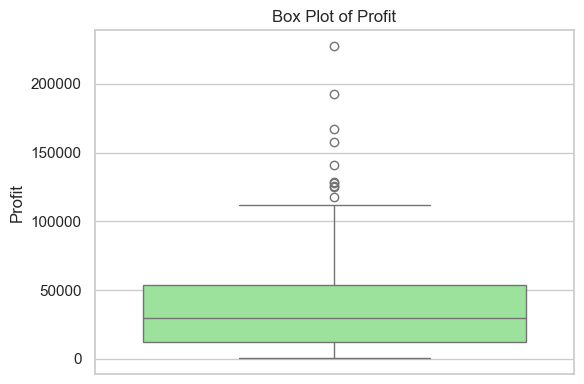

In [19]:
# 13. Create a box plot for Profit
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Profit"], color="lightgreen")
plt.title("Box Plot of Profit")
plt.tight_layout()
plt.show()

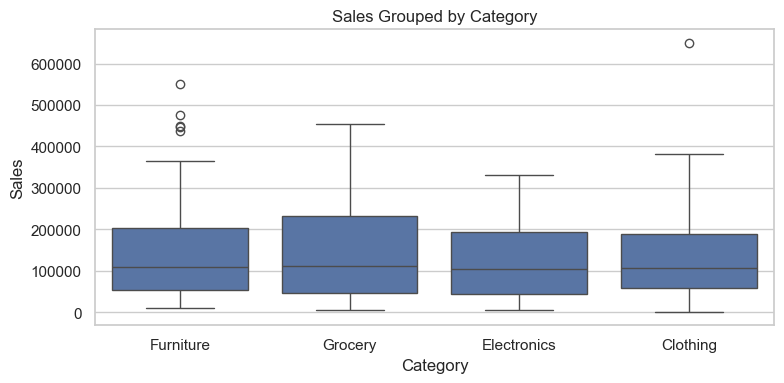

In [20]:
# 14. Create a box plot of Sales grouped by Category
plt.figure(figsize=(8, 4))
sns.boxplot(x="Category", y="Sales", data=df)
plt.title("Sales Grouped by Category")
plt.tight_layout()
plt.show()

In [21]:
# 15. Identify possible outliers (Prints IQR bounds for Sales)
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["Sales"] < (Q1 - 1.5 * IQR)) | (df["Sales"] > (Q3 + 1.5 * IQR))]
print(f"Number of potential outliers in Sales: {len(outliers)}")

Number of potential outliers in Sales: 7


# 5. Pie Chart

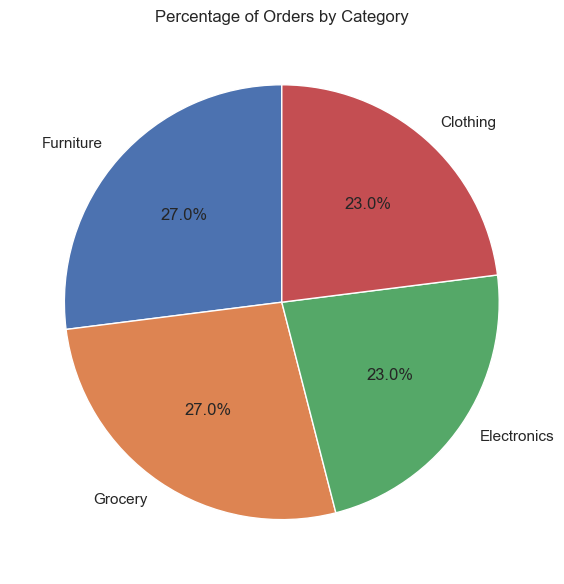

In [22]:
# 16. Show the percentage of orders by Category
plt.figure(figsize=(6, 6))
df["Category"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Percentage of Orders by Category")
plt.ylabel("")
plt.tight_layout()
plt.show()

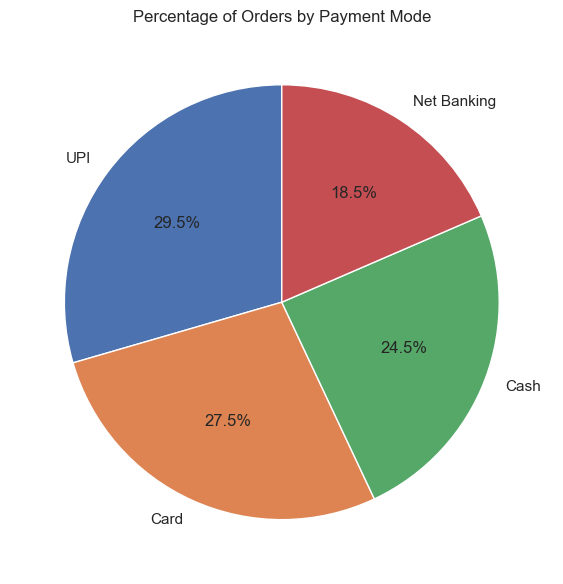

In [23]:
# 17. Show the percentage of orders by Payment_Mode
plt.figure(figsize=(6, 6))
df["Payment_Mode"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Percentage of Orders by Payment Mode")
plt.ylabel("")
plt.tight_layout()
plt.show()

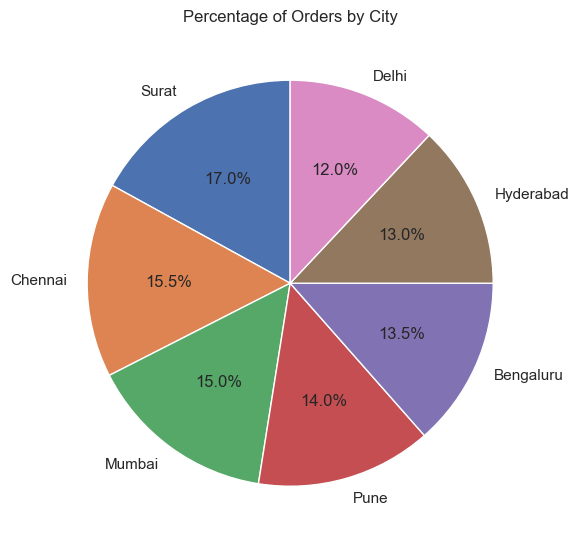

In [24]:
# 18. Show the percentage of customers/orders by City
plt.figure(figsize=(6, 6))
df["City"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Percentage of Orders by City")
plt.ylabel("")
plt.tight_layout()
plt.show()